In [1]:
!pip install seaborn



[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install missingno



[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# importing libraries fundamentals

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy as sp
import warnings
import datetime
from matplotlib import pyplot

# Library for Null Values Imputing
import missingno as msno
from sklearn.impute import KNNImputer

In [4]:
# Library for Encoding and Imputer
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

In [5]:
import sys
print(sys.version)


3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


In [6]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [7]:
# Library for Deep Learning Frameworks
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from keras.layers import *

In [8]:
folder_path = r"D:\PTDLKinhDoanh\Dataset\Natural_Gas_data.csv"
df = pd.read_csv(folder_path) 

print(df.head()) 


         date  open   high   low  close  volume
0  2000-08-30  4.65  4.815  4.63  4.805   34954
1  2000-08-31  4.82  4.870  4.74  4.780   25787
2  2000-09-01  4.75  4.860  4.75  4.835     113
3  2000-09-05  4.85  4.975  4.84  4.960   26096
4  2000-09-06  4.99  5.110  4.96  5.065   32764


In [9]:
print(df.shape)

(5980, 6)


In [10]:
df.describe()

,open,high,low,close,volume
count,5980.000000,5980.000000,5980.000000,5980.000000,5980.000000
mean,4.473549,4.579886,4.365687,4.468276,102846.481605
std,2.248934,2.312086,2.187833,2.247718,63233.577171
min,1.441000,1.567000,1.432000,1.482000,0.000000
25%,2.800750,2.852000,2.743000,2.797000,45950.000000
50%,3.837500,3.922000,3.761000,3.828500,98166.000000
75%,5.658250,5.793750,5.510000,5.646250,145383.500000
max,15.160000,15.780000,14.851000,15.378000,459196.000000


mô tả thống kê các cột có kiểu dữ liệu chuỗi (object) trong DataFrame.

In [11]:
df.describe(include='object').T

,count,unique,top,freq
date,5980,5980,2000-08-30,1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5980 entries, 0 to 5979
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    5980 non-null   object 
 1   open    5980 non-null   float64
 2   high    5980 non-null   float64
 3   low     5980 non-null   float64
 4   close   5980 non-null   float64
 5   volume  5980 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 280.4+ KB


 trích xuất các cột kiểu dữ liệu phân loại (categorical)

In [13]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
print(cat_cols)

Index(['date'], dtype='object')


trích xuất các cột có kiểu dữ liệu số 

In [14]:
num_cols = df.select_dtypes(include=['float', 'int64']).columns
print(num_cols)

Index(['open', 'high', 'low', 'close', 'volume'], dtype='object')


Xử lý time - Đặt date làm index giúp truy xuất nhanh hơn

In [15]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.sort_index(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5980 entries, 2000-08-30 to 2024-06-24
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    5980 non-null   float64
 1   high    5980 non-null   float64
 2   low     5980 non-null   float64
 3   close   5980 non-null   float64
 4   volume  5980 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 280.3 KB


In [16]:
df.head()

,open,high,low,close,volume
date,,,,,
2000-08-30,4.65,4.815,4.63,4.805,34954
2000-08-31,4.82,4.870,4.74,4.780,25787
2000-09-01,4.75,4.860,4.75,4.835,113
2000-09-05,4.85,4.975,4.84,4.960,26096
2000-09-06,4.99,5.110,4.96,5.065,32764


Scaling Data (Chỉ áp dụng cho cột số - Num Cols): Chuẩn hóa dữ liệu số

In [17]:
list_num_cols = [ 'open', 'high', 'low', 'volume' ]

 chuẩn hóa dữ liệu theo công thức Z-score

In [18]:
scaler = StandardScaler()
df[list_num_cols] = scaler.fit_transform(df[list_num_cols])

In [19]:
print(df[list_num_cols])

                open      high       low    volume
date                                              
2000-08-30  0.078466  0.101697  0.120821 -1.073767
2000-08-31  0.154064  0.125487  0.171103 -1.218750
2000-09-01  0.122935  0.121162  0.175674 -1.624802
2000-09-05  0.167405  0.170905  0.216814 -1.213863
2000-09-06  0.229661  0.229299  0.271667 -1.108404
...              ...       ...       ...       ...
2024-06-17 -0.723759 -0.749121 -0.734435  0.781209
2024-06-18 -0.756666 -0.719708 -0.728493  0.704867
2024-06-20 -0.698411 -0.705866 -0.750891  1.325981
2024-06-21 -0.777566 -0.782859 -0.774204 -0.371265
2024-06-24 -0.802024 -0.755176 -0.791117 -0.371265

[5980 rows x 4 columns]


Tách dữ liệu & sắp xếp dữ liệu

X là danh sách chứa các cửa sổ (windows) có window_size dòng dữ liệu.


y là danh sách chứa giá trị giá đóng cửa (close) của ngày ngay sau mỗi cửa sổ.

X[0] = [[100, 105, 98, 102], 
        [102, 107, 100, 104], 
        [104, 110, 102, 106], 
        [106, 112, 104, 108], 
        [108, 115, 106, 110]]  
=> y[0] = 112 (giá đóng cửa của ngày tiếp theo)


X[1] = [[102, 107, 100, 104], 
        [104, 110, 102, 106], 
        [106, 112, 104, 108], 
        [108, 115, 106, 110], 
        [110, 117, 108, 112]]  
=> y[1] = 114 (giá đóng cửa của ngày tiếp theo)

In [20]:
window_size = 5

def create_multivariate_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        #i = 0, window_size = 5: lấy dữ liệu từ index 0 -> index 4 và chuyển sang mảng
        X.append(data.iloc[i:i + window_size].values)
        #y[0] = data.iloc[5]['close'] = 112
        y.append(data.iloc[i + window_size]['close'])  # Adjust if predicting a different column
    return np.array(X), np.array(y)

In [21]:
#X sẽ chứa toàn bộ các cột đặc trưng (features).
#y chứa close
X, y = create_multivariate_sequences(df, window_size)
X.shape, y.shape

((5975, 5, 5), (5975,))

In [22]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape 

((4182, 5, 5), (4182,), (896, 5, 5), (896,), (897, 5, 5), (897,))

Long Short Term Memory (LSTM)

Build Model 1

In [23]:
# Build simple model for LSTM
def build_model_lstm1():
    model = Sequential()
    model.add(InputLayer((5, 5))) # input layer with was timesteps, features
    model.add(LSTM(64))
    model.add(Dense(8, 'relu'))
    model.add(Dense(1, 'linear'))
    return model

model1 = build_model_lstm1()
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,449 (72.07 KB)

 Trainable params: 18,449 (72.07 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# make checkpoint for each models has been compile

cp1 = ModelCheckpoint('model1.keras', save_best_only=True)
model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [25]:
# Train the model
history1 = model1.fit(X_train, y_train, 
                        validation_split=0.3, 
                        epochs=150, 
                        batch_size=32, 
                        callbacks=[cp1]
                     )

Epoch 1/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 40.4877 - root_mean_squared_error: 6.3586 - val_loss: 9.6697 - val_root_mean_squared_error: 3.1096
Epoch 2/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 34.1965 - root_mean_squared_error: 5.8467 - val_loss: 7.7248 - val_root_mean_squared_error: 2.7794
Epoch 3/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 28.4107 - root_mean_squared_error: 5.3288 - val_loss: 5.2056 - val_root_mean_squared_error: 2.2816
Epoch 4/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 21.9137 - root_mean_squared_error: 4.6785 - val_loss: 2.5202 - val_root_mean_squared_error: 1.5875
Epoch 5/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 14.8244 - root_mean_squared_error: 3.8482 - val_loss: 0.7881 - val_root_mean_squared_error: 0.8877
Epoch 6/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.8975 - root_mean_squared_error: 3.1453 - val_loss: 0.1704 - val_root_mean_squared_error: 0.4128
Epoch 7/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/

In [26]:
from tensorflow.keras.models import load_model
model_pred1 = load_model('model1.keras')

In [27]:
print(y_train[:5])

[4.99800014 4.88000011 5.01499987 5.00500011 5.05499983]


Tạo DataFrame có 2 cột

In [28]:
train_predictions = model1.predict(X_train).flatten()
train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals':y_train})


131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


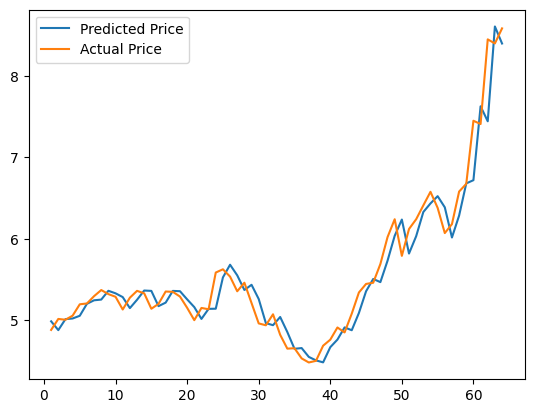

In [29]:
plt.plot(train_results['Train Predictions'][1:65],label='Predicted Price' )
plt.plot(train_results['Actuals'][1:65], label='Actual Price')
plt.legend()

Giá trị MAE càng nhỏ, mô hình càng chính xác: MAE đo lường độ chênh lệch trung bình giữa giá trị thực tế và dự đoán.

Giá trị MSE nhỏ → Mô hình hoạt động tốt: trung bình bình phương của sai số, giúp phạt nặng hơn các sai số lớn.

RMSE càng nhỏ, mô hình càng tốt: RMSE giúp diễn giải lỗi theo đơn vị gốc của biến đầu ra.

R² càng gần 1, mô hình càng tốt.

In [30]:
# Metrics Performance 

y_pred1 = model1.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred1)}')
print(f'MSE: {mean_squared_error(y_test, y_pred1)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred1))}')
print(f'R²: {r2_score(y_test, y_pred1)}')

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MAE: 0.15356038725097043
MSE: 0.05639330199707449
RMSE: 0.23747273948197611
R²: 0.9854542994924895


MAE thấp (0.154) → Sai số trung bình nhỏ.
RMSE thấp (0.236) → Sai số thấp hơn nhiều so với phạm vi giá trị.
R² cao (0.9856) → Mô hình dự đoán tốt, giải thích được 98.56% biến động dữ liệu.

Build Model 2 -- Conv1D

Mô hình Conv1D phù hợp nếu dữ liệu có xu hướng ngắn hạn, trong khi LSTM phù hợp hơn với xu hướng dài hạn.

In [31]:
def build_model_lstm2():
    model = Sequential()
    model.add(InputLayer((5, 5))) # input layer for window size and train size (features dimensions)
    model.add(Conv1D(128, kernel_size=2, activation='relu'))
    model.add(Flatten())
    model.add(Dense(8, 'relu'))
    model.add(Dense(1, 'linear'))
    model.summary()
    return model

model2 = build_model_lstm2()
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4, 128)         │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         4,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,521 (21.57 KB)

 Trainable params: 5,521 (21.57 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4, 128)         │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         4,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,521 (21.57 KB)

 Trainable params: 5,521 (21.57 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# make checkpoint for each models has been compile

cp2 = ModelCheckpoint('model2.keras', save_best_only=True)
model2.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [33]:
# Train the model

history2 = model2.fit(X_train, y_train, 
                    validation_split=0.3, 
                    epochs=150, 
                    batch_size=32, 
                    callbacks=[cp2])

Epoch 1/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 20.8735 - root_mean_squared_error: 4.5530 - val_loss: 2.6137 - val_root_mean_squared_error: 1.6167
Epoch 2/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.2050 - root_mean_squared_error: 1.7681 - val_loss: 0.4880 - val_root_mean_squared_error: 0.6986
Epoch 3/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3548 - root_mean_squared_error: 0.5944 - val_loss: 0.1245 - val_root_mean_squared_error: 0.3529
Epoch 4/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2096 - root_mean_squared_error: 0.4575 - val_loss: 0.0604 - val_root_mean_squared_error: 0.2459
Epoch 5/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1832 - root_mean_squared_error: 0.4278 - val_loss: 0.0558 - val_root_mean_squared_error: 0.2362
Epoch 6/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1516 - root_mean_squared_error: 0.3892 - val_loss: 0.0451 - val_root_mean_squared_error: 0.2123
Epoch 7/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - lo

In [34]:
from tensorflow.keras.models import load_model
model_pred1 = load_model('model2.keras')

In [35]:
train_predictions = model2.predict(X_train).flatten()
train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals':y_train})
train_results

131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


,Train Predictions,Actuals
0,5.056755,4.998
1,4.965720,4.880
2,4.861703,5.015
3,5.017798,5.005
4,5.021897,5.055
...,...,...
4177,3.208494,3.228
4178,3.195718,3.186
4179,3.228891,3.266
4180,3.248096,3.172


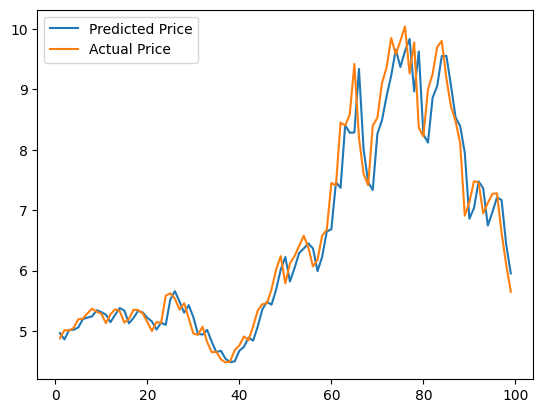

In [36]:
plt.plot(train_results['Train Predictions'][1:100], label='Predicted Price' )
plt.plot(train_results['Actuals'][1:100], label='Actual Price')
plt.legend()

In [37]:
y_pred2 = model2.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred2)}')
print(f'MSE: {mean_squared_error(y_test, y_pred2)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred2))}')
print(f'R²: {r2_score(y_test, y_pred2)}')

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
MAE: 0.16963748402951687
MSE: 0.06291998328973039
RMSE: 0.2508385602129991
R²: 0.9837708522030247


Train Loss Val Loss

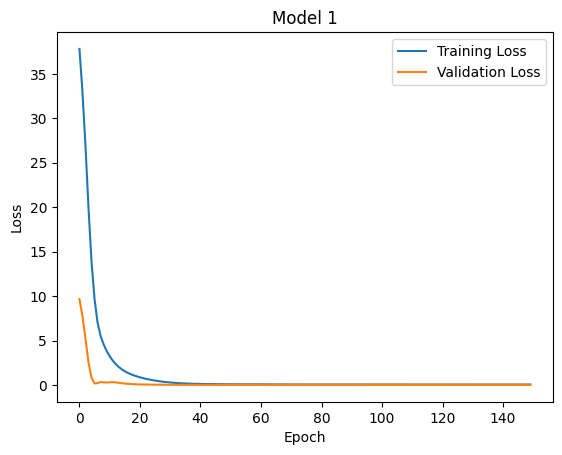

In [38]:
plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.title('Model 1')
plt.ylabel('Loss')
plt.legend()
plt.show()

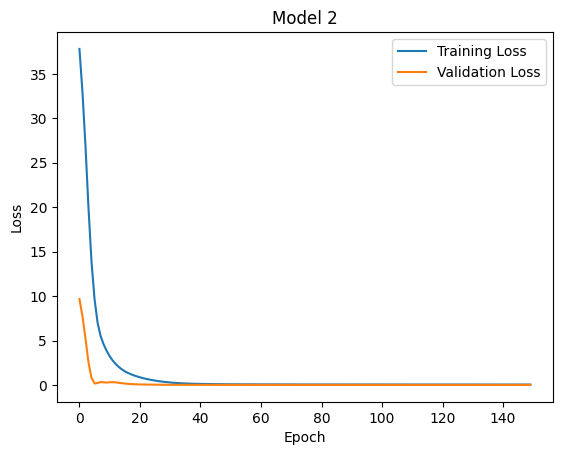

In [39]:
plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.title('Model 2')
plt.ylabel('Loss')
plt.legend()
plt.show()

tạo dự báo từ mô hình đã lưu

In [40]:
from tensorflow.keras.models import load_model

# Tải mô hình đã lưu
model1_loaded = load_model('model1.h5')

In [41]:
import numpy as np

# Ví dụ: Một mẫu dữ liệu mới có 5 bước thời gian, 5 đặc trưng (giống lúc huấn luyện)
X_new = np.array([[
    [4.650, 4.815, 4.630, 4.804, 34954],
    [4.820, 4.870, 4.740, 4.780, 25787],
    [4.750, 4.860, 4.750, 4.835, 113],
    [4.850, 4.975, 4.840, 4.960, 26096],
    [4.990, 5.110, 4.960, 5.065, 32764]
]])  # Kích thước: (1, 5, 5) => (samples, timesteps, features)

In [42]:
model1.save('model1.h5')
model2.save('model2.h5')